<a href="https://colab.research.google.com/github/MauriceCC04/Stochastic-Processes-BAI-Bocconi/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#3D Ising model (extension of the 2D model Ising model described in the course to 3D)
#show magnetization as a function of temperature, for different values of the number of spins N

3D Ising Model Setup

H = -J(∑sᵢsⱼ) - (h∑s\_i)

J is the interaction strength (positive for ferromagnetic interaction)

i and j neighbors

h external magnetic field
P(sᵢ) = 1/Z *exp(H(sᵢ) / (KT)) where
Z = ∑exp(H(sᵢ) / (KT))

All configs unfeasible in 2d

So need to use a Monte Carlo Algorithm, for example Metropolis
Then it is no longer necessary to calculate Z
Goal:
Show the magnetization as a function of temperature, for different values of the number of spins N

In [ ]:
pip install tqdm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit

Metropolis Algorithm Implementation:

    The acceptance probability exp(-ΔE/T) is derived from the Boltzmann distribution

    This ensures simulation samples configurations according to their thermal probability

    ΔE < 0 moves are always accepted as they lower the energy

    ΔE > 0 moves are accepted with probability exp(-ΔE/T), allowing thermal fluctuations

In [ ]:
#Initialize lattice with random spins (+1 or -1)
#NxNxN cube of spins with spin 1 or -1
@njit
def initialize_lattice(N):
    # Convert the list of choices to a NumPy array for Numba compatibility
    return np.random.choice(np.array([1, -1]), size=(N, N, N))

In [ ]:
#Calculate energy change for flipping spin at (i, j, k), with periodic boundaries
@njit
def delta_energy(lattice, N, i, j, k, J, h):
    #Periodic neighbor indices
    #% N for if at thte edge of a lattice
    neighbors = [
        ((i + 1) % N, j, k),
        ((i - 1) % N, j, k),
        (i, (j + 1) % N, k),
        (i, (j - 1) % N, k),
        (i, j, (k + 1) % N),
        (i, j, (k - 1) % N)
    ]
    spin = lattice[i, j, k]
    #sums the values of the spins at those neighboring coordinates
    neighbor_sum = 0.0
    for x, y, z in neighbors:
        neighbor_sum += lattice[x, y, z]
    #from energy formula in ising
    dE = 2 * J * spin * neighbor_sum + 2 * h * spin
    return dE

In [ ]:
#Perform N^3 attempted spin flips
@njit
def monte_carlo_step(lattice, N, T, J, h):
    for _ in range(N*N*N):
        # Random lattice site
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        k = np.random.randint(0, N)
        dE = delta_energy(lattice, N, i, j, k, J, h)
        #conditions to flip the spin under metropolis
        #flips if dE is negative
        #flips if dE is positive with a probabilitiy
        if dE <= 0:
            lattice[i, j, k] *= -1 #Flip spin
        else:
            if np.random.rand() < np.exp(-dE / T):
                lattice[i, j, k] *= -1  #Flip spin

In [ ]:
#Compute average magnetization per spin
@njit
def compute_magnetization(lattice):
    return np.abs(np.sum(lattice)) / lattice.size

In [ ]:
#the following functions are written outside the simulation function to allow for faster runtime using numba
#function to loop through monte carlo steps
@njit
def run_mc_steps(lattice, N, T, J, h, num_steps):
    for _ in range(num_steps):
        monte_carlo_step(lattice, N, T, J, h)

In [ ]:
#function measure magnetization
@njit
def measure_magnetization_over_steps(lattice, N, T, J, num_steps, h):
    mags = np.empty(num_steps) #Use empty array for Numba compatibility
    for i in range(num_steps): #iterate over step param
        monte_carlo_step(lattice, N, T, J, h) #monte carlo step
        mags[i] = compute_magnetization(lattice) #add the magnetization at step
    return np.mean(mags)

In [ ]:
#Run simulation for a given lattice size N and a sequence of temperatures
#Returns: list of average magnetizations for each temperature
def simulate_ising(N, temperatures, J, h, equilibration_steps=1500, measurement_steps=1500, progress=False):
  #initialize magnetizations
    magnetizations = []
    #iterate through temperatures at N
    #for numba
    temp_loop = tqdm(temperatures, desc=f"Simulating N={N}, J={J}, h={h}", disable=not progress)

    for T in temp_loop:
        #Initialize lattice
        lattice = initialize_lattice(N)

        #Equilibration phase, loop through monte carlo steps
        run_mc_steps(lattice, N, T, J, h, equilibration_steps)

        #Measureming the magnetization
        avg_mag = measure_magnetization_over_steps(lattice, N, T, J, measurement_steps, h)
        magnetizations.append(avg_mag)

    return magnetizations

In [ ]:
#Plot Magnetization vs. Temperature for different lattice sizes N.
def plot_results(temperature_range, magnetizations_dict, J, h):
    plt.figure(figsize=(8,6))
    for N, mags in magnetizations_dict.items():
        plt.plot(temperature_range, mags, marker='o', label=f'N={N}')
    plt.xlabel('Temperature (T)', fontsize=14)
    plt.ylabel('Magnetization per spin', fontsize=14)
    plt.title(f'3D Ising Model: Magnetization vs. Temperature for J = {J} and h = {h}', fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Parameter Selection Rationale

Lattice Sizes (N = [1, 5, 10, 15, 20]):

    N=1: Single-spin case (trivial)

    N=5: Small system with strong finite-size effects

    N=10-15: Begins to show bulk behavior while remaining computationally feasible

    N=20: Approaching thermodynamic limit for observing phase transition

    Larger N values would provide better approximation of infinite system but are computationally expensive

Temperature Range (T_min=2.5, T_max=6.0, num_T=1000):

    Range deliberately brackets the theoretical critical temperature (Tc ≈ 4.51) for 3D Ising model

    High temperature resolution (1000 points) allows detailed observation of the phase transition

Monte Carlo Steps:

    Equilibration_steps = 1500: Sufficient for system to reach thermal equilibrium before measurements
    (For very large systems or near Tc, more steps would be needed due to critical slowing down)

    Measurement_steps = 1500: Provides adequate statistical sampling for reliable magnetization values

    These values balance statistical accuracy with computational efficiency

Interaction and Field Parameters (J = [1, 0, -1], h = [0, 1, -1]):

    J=1: Ferromagnetic coupling (parallel spin alignment energetically favorable)

    J=0: Non-interacting spins (only external field matters)

    J=-1: Antiferromagnetic coupling (anti-parallel alignment favorable)

    h=0: No external field (system has up/down symmetry)

    h=±1: External field biasing system toward spin alignment with field direction

    These 9 combinations cover the fundamental physical regimes of the Ising model

In [ ]:
def process(lattice_sizes, J, h):
    #Simulation parameters
    #num_T, equilibration_steps, measurement_steps chosen to be sufficiently large
    #Large which allows for accuracy however at the cost of computational time

    k_B = 1                 #Boltzmann constant (irrelevant since J/k_B = constant)
    T_min = 2.5             #Lower bound for temperature (close to expected Tc ≈ 4.5)
    T_max = 6.0             #Upper bound
    num_T = 1000              #Number of temperature points
    #create an appropriate temperature range to see the behavior, for observing the transition around the expected Tc ≈ 4.51
    temperature_range = np.linspace(T_min, T_max, num_T)

    #the following parameters chosen significantly large to accurately model the model, despite the runtime
    equilibration_steps = 1500 #MC sweeps for equilibration
    measurement_steps   = 1500 #MC sweeps for measurement

    #Store results in a dict
    magnetizations_dict = {}

    for N in lattice_sizes:#loop through the lattice sizes e.g. N = 1, 5, ..
        magnetizations = simulate_ising(
            N, temperature_range, J, h,
            equilibration_steps=equilibration_steps,
            measurement_steps=measurement_steps,
            progress=True
        )
        magnetizations_dict[N] = magnetizations

    # Plotting results
    plot_results(temperature_range, magnetizations_dict, J, h)

Simulating N=20, J=1, h=0: 100%|██████████| 1000/1000 [1:59:41<00:00,  7.18s/it]


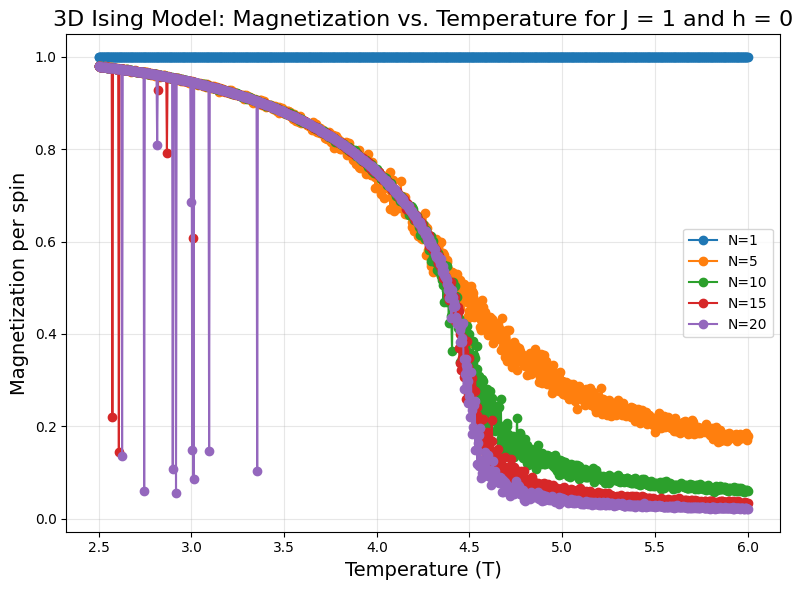

In [ ]:
#show ising spins for arbitrary J = 1, h = 0 then change params
process([1, 5, 10, 15, 20], 1, 0)

Simulating N=15, J=1, h=0: 100%|██████████| 1000/1000 [25:59<00:00,  1.56s/it]


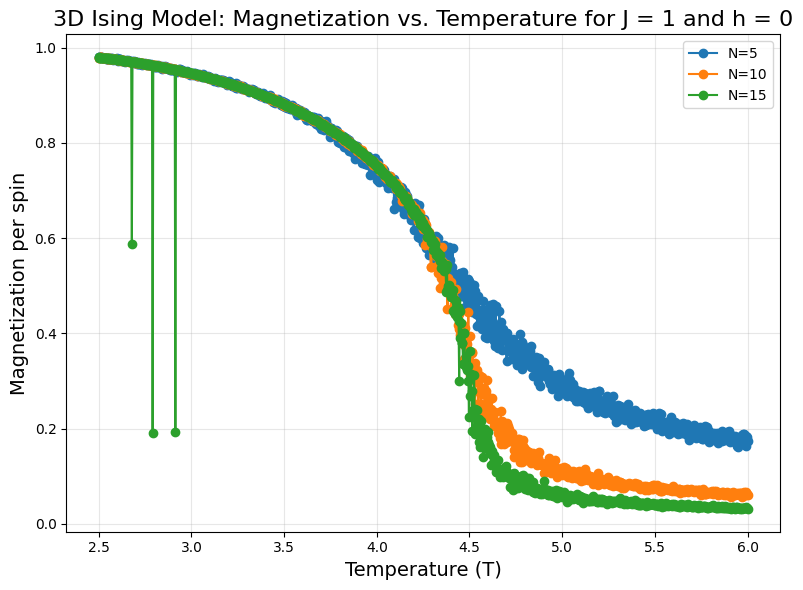

Simulating N=15, J=1, h=1: 100%|██████████| 1000/1000 [26:00<00:00,  1.56s/it]


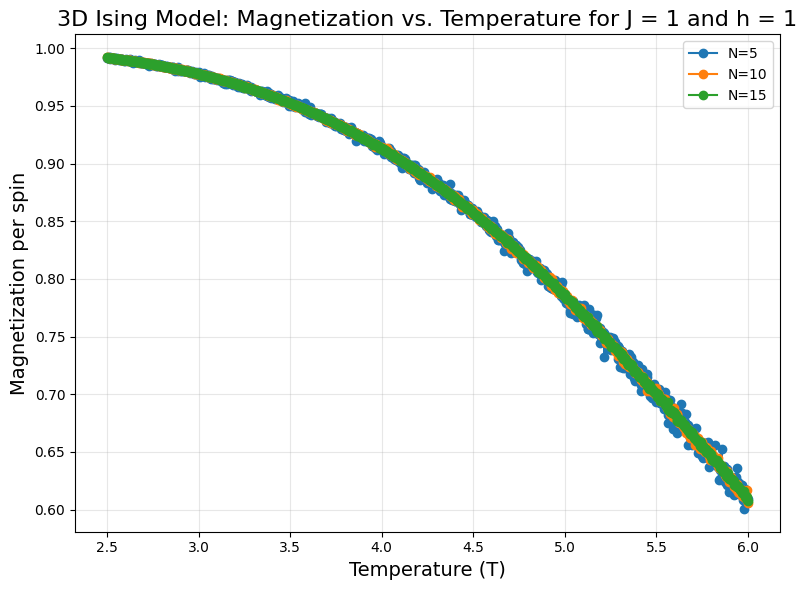

Simulating N=15, J=1, h=-1: 100%|██████████| 1000/1000 [25:58<00:00,  1.56s/it]


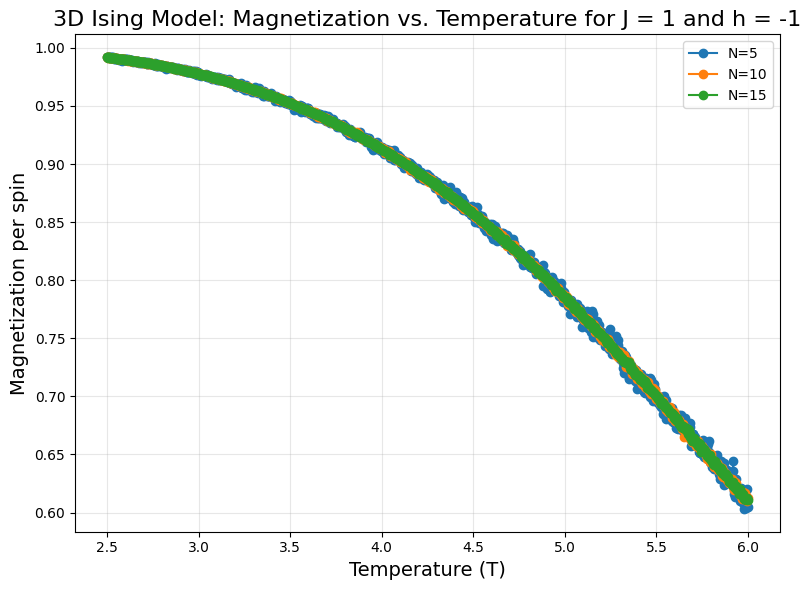

Simulating N=15, J=0, h=0: 100%|██████████| 1000/1000 [21:14<00:00,  1.27s/it]


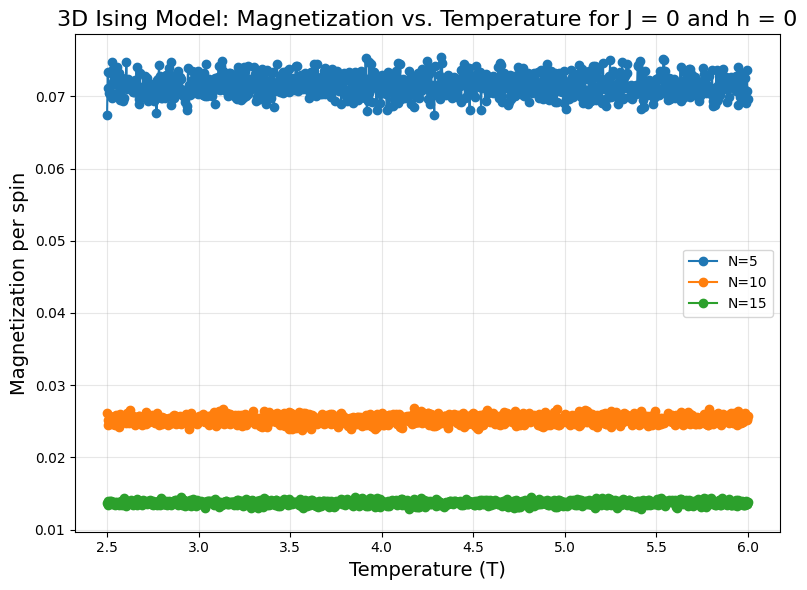

Simulating N=15, J=0, h=1: 100%|██████████| 1000/1000 [26:19<00:00,  1.58s/it]


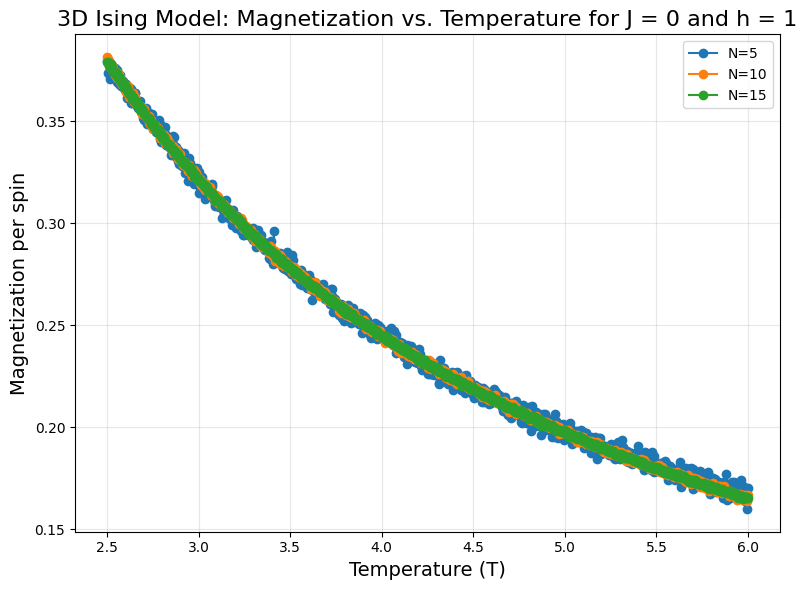

Simulating N=15, J=0, h=-1: 100%|██████████| 1000/1000 [26:27<00:00,  1.59s/it]


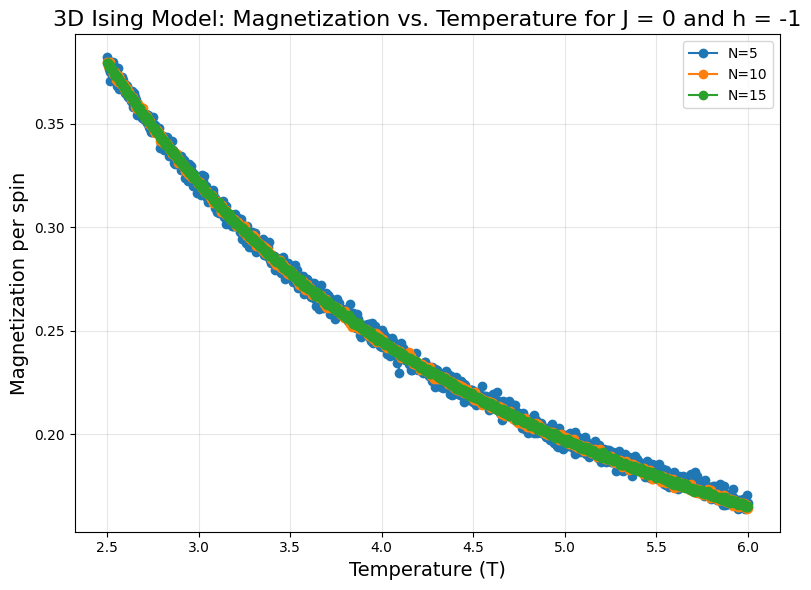

Simulating N=15, J=-1, h=0: 100%|██████████| 1000/1000 [25:59<00:00,  1.56s/it]


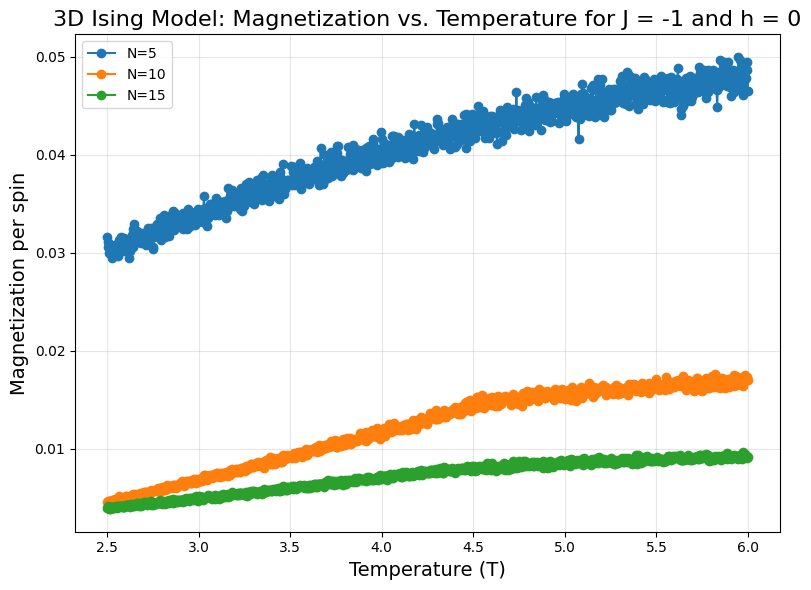

Simulating N=15, J=-1, h=1: 100%|██████████| 1000/1000 [26:22<00:00,  1.58s/it]


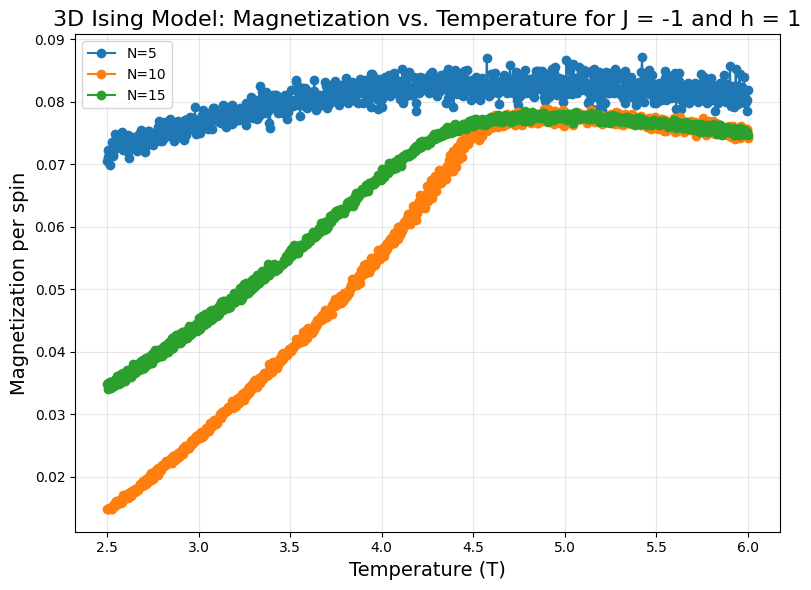

Simulating N=15, J=-1, h=-1: 100%|██████████| 1000/1000 [26:19<00:00,  1.58s/it]


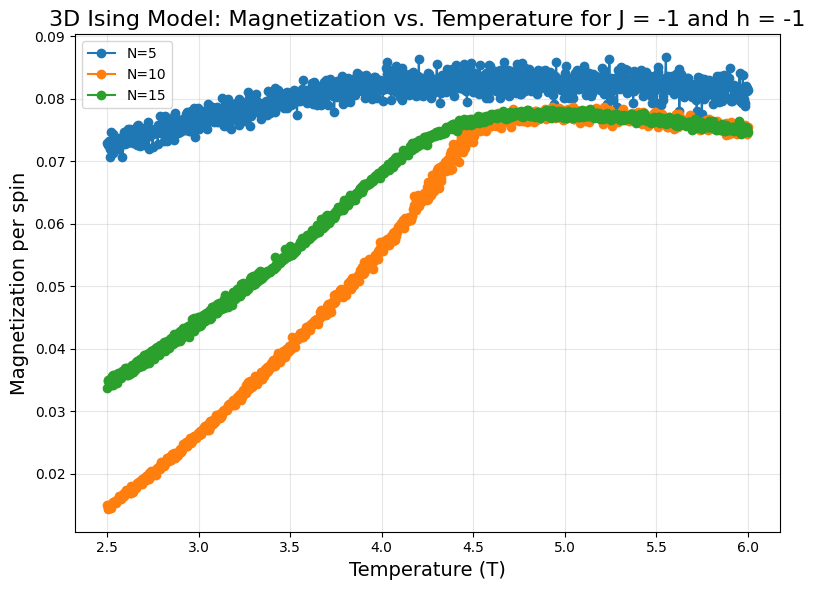

In [ ]:
#iterate through different J and h values to show the combinations for different N values
Js = [1, 0, -1] #Need only J = 1 and J = -1, simulating at (J = 2, T) is similar to simulating at (J = 1, T/2)
hs = [0, 1, -1]
for J in Js:
    for h in hs:
        process([5, 10, 15], J, h)

## Comprehensive Analysis of 3D Ising Model Behavior

### Ferromagnetic Coupling (J = 1, h = 0)
The results show the hallmark of a second-order phase transition around T ≈ 4.5, consistent with the
theoretical critical temperature of Tc ≈ 4.51 for the 3D Ising model. Several key observations:
   
1. **Finite-Size Effects**: Smaller lattices (N=5) show a more gradual transition compared to
   larger lattices (N=15, N=20). This is because:
   - Correlation length is limited by system size
   - Fluctuations are more significant in smaller systems
   - The apparent critical temperature shifts with system size


### Non-Interacting Case (J = 0)
When J=0, spins don't interact with each other, and we observe:

1. **No Phase Transition**: Without spin-spin interactions, no cooperative phenomena occur
   
2. **Field Response**: At h=0: All temperatures show zero magnetization (random orientation)

### Antiferromagnetic Coupling (J = -1)
1. **True Antiferromagnetic Order**: Neighboring spins prefer opposite alignment
   
### External Field Effects (h = ±1)
External fields fundamentally alter phase behavior:

1. **Symmetry Breaking**: Any non-zero h explicitly breaks the up/down symmetry
      
2. **Field Direction**: Positive field (h=1) favors spin-up states, while negative field (h=-1) favors spin-down, with identical magnetization magnitude behavior

For a more comprehensive analysis, we would need to calculate additional observables including energy, specific heat, susceptibility, and correlation functions, as well as perform systematic scaling analysis with larger lattice sizes.